In [1]:
import sys
sys.path.append("../../")

import torch
from src.models.autoencoder import AutoencoderLSTM

# Creamos el modelo
modelo = AutoencoderLSTM(n_features=3, dim_latente=32, seq_len=30)
print(modelo)

# Probamos con un batch falso: 8 secuencias de 30 días con 3 features
x_prueba = torch.randn(8, 30, 3)
reconstruccion = modelo(x_prueba)

print(f"\nShape entrada:       {x_prueba.shape}")
print(f"Shape reconstrucción: {reconstruccion.shape}")
print(f"¿Shapes iguales?: {x_prueba.shape == reconstruccion.shape}")

AutoencoderLSTM(
  (codificador): CodificadorLSTM(
    (lstm): LSTM(3, 32, batch_first=True)
  )
  (decodificador): DecodificadorLSTM(
    (lstm): LSTM(32, 3, batch_first=True)
  )
)

Shape entrada:       torch.Size([8, 30, 3])
Shape reconstrucción: torch.Size([8, 30, 3])
¿Shapes iguales?: True


In [2]:
import torch
from torch.utils.data import DataLoader, TensorDataset

# Simulamos nuestras secuencias reales
X_tensor = torch.randn(957, 30, 3)

# TensorDataset envuelve el tensor para que DataLoader pueda trabajar con él
dataset = TensorDataset(X_tensor)

# DataLoader divide automáticamente en batches y los baraja en cada epoch
loader = DataLoader(dataset, batch_size=32, shuffle=True)

print(f"Total secuencias: {len(dataset)}")
print(f"Total batches por epoch: {len(loader)}")
print(f"Shape de un batch: {next(iter(loader))[0].shape}")

Total secuencias: 957
Total batches por epoch: 30
Shape de un batch: torch.Size([32, 30, 3])


In [3]:
from src.models.autoencoder import AutoencoderLSTM
from src.models.trainer import Entrenador
from src.data.ingestion import cargar_raw
from src.data.preprocessing import pipeline

df = cargar_raw("AAPL")
X, scaler = pipeline(df)

modelo = AutoencoderLSTM(n_features=3, dim_latente=32, seq_len=30)
entrenador = Entrenador(modelo, lr=0.001, batch_size=32, paciencia=10)
entrenador.entrenar(X, epochs=50)

2026-02-27 02:59:21.003 | INFO     | src.data.preprocessing:pipeline:78 - Iniciando pipeline de preprocesamiento...
2026-02-27 02:59:21.005 | INFO     | src.data.preprocessing:calcular_caract:16 - Calculando caract con ventana=20
2026-02-27 02:59:21.014 | INFO     | src.data.preprocessing:calcular_caract:33 - Características calculadas: Filas: 1006 -> 987(eliminadas 1006 - 987 por NaN)
2026-02-27 02:59:21.015 | INFO     | src.data.preprocessing:normalizar:48 - Normalización de características
2026-02-27 02:59:21.031 | INFO     | src.data.preprocessing:construir_secuencias:67 - Secuencias construidas: 957 secuencias de 30 días × 3 features
2026-02-27 02:59:21.034 | INFO     | src.data.preprocessing:pipeline:82 - Pipeline completado. Tamaño final: (957, 30, 3)
2026-02-27 02:59:23.420 | INFO     | src.models.trainer:entrenar:46 - Entrenamiento: 862 secuencias | Validación: 95 secuencias | Batch size: 32
2026-02-27 02:59:25.659 | INFO     | src.models.trainer:entrenar:80 - Epoch 10/50 | Tr

In [4]:
import numpy as np

# Calculamos el error de reconstrucción para cada secuencia
modelo.eval()
X_tensor = torch.FloatTensor(X)

with torch.no_grad():
    reconstruccion = modelo(X_tensor)

# Error por secuencia: media del MSE en cada día y feature
errores = torch.mean((X_tensor - reconstruccion) ** 2, dim=(1, 2))
errores = errores.numpy()

print(f"Error medio:  {errores.mean():.6f}")
print(f"Error máximo: {errores.max():.6f}")
print(f"Error mínimo: {errores.min():.6f}")

Error medio:  0.010837
Error máximo: 0.040463
Error mínimo: 0.001941


Fechas: 957, Errores: 957
Umbral: 0.026066
Anomalías detectadas: 54 de 957 secuencias


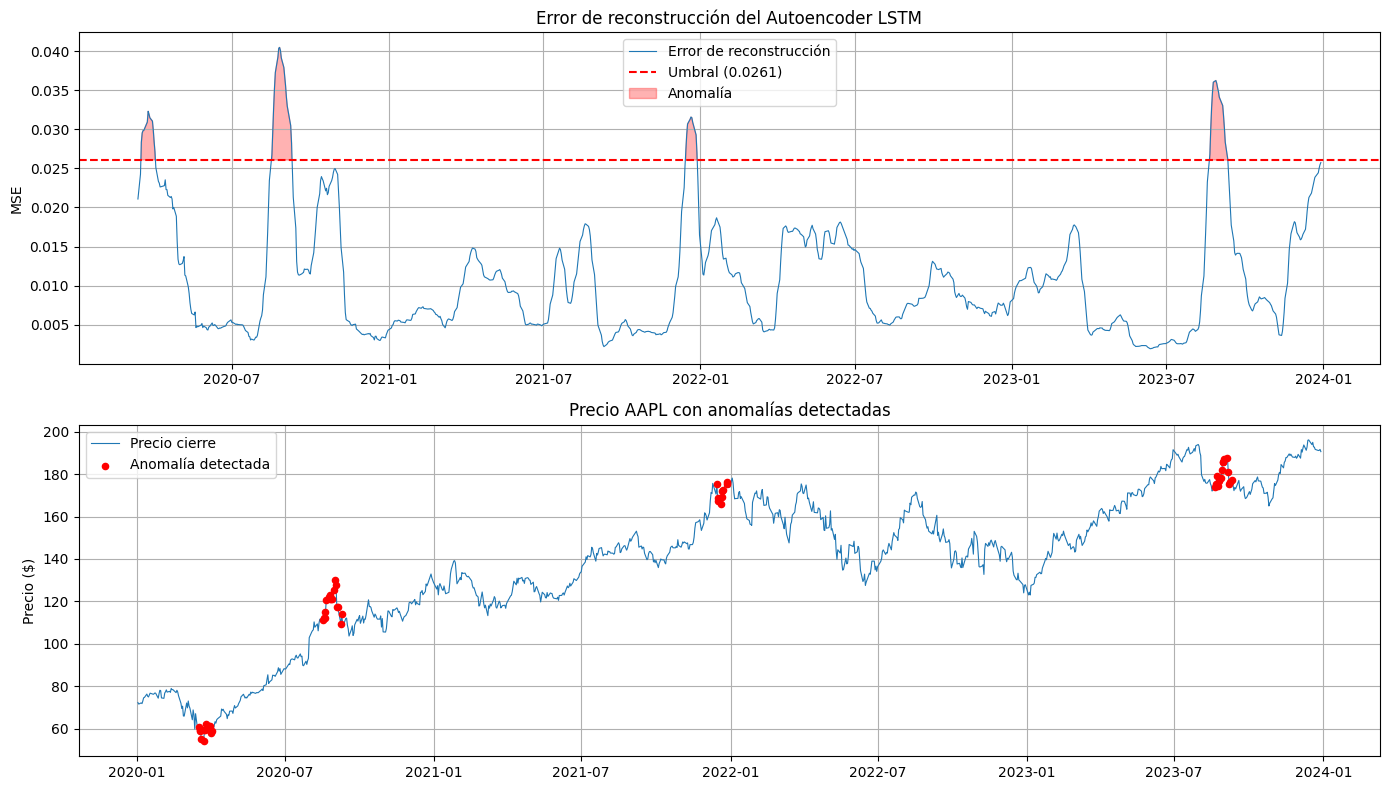

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from src.data.ingestion import cargar_raw

df = cargar_raw("AAPL")

# Las fechas de las secuencias empiezan en el día seq_len
# porque los primeros 30 días se usan para formar la primera secuencia
offset = len(df) - len(errores)
fechas = df.index[offset:]
fechas = fechas[:len(errores)]

print(f"Fechas: {len(fechas)}, Errores: {len(errores)}")

# Definimos el umbral como media + 2 desviaciones estándar
umbral = errores.mean() + 2 * errores.std()
anomalias = errores > umbral

print(f"Umbral: {umbral:.6f}")
print(f"Anomalías detectadas: {anomalias.sum()} de {len(errores)} secuencias")

# Visualización
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Gráfica 1: error de reconstrucción con umbral
axes[0].plot(fechas, errores, label="Error de reconstrucción", linewidth=0.8)
axes[0].axhline(umbral, color="red", linestyle="--", label=f"Umbral ({umbral:.4f})")
axes[0].fill_between(fechas, errores, umbral, where=anomalias, color="red", alpha=0.3, label="Anomalía")
axes[0].set_title("Error de reconstrucción del Autoencoder LSTM")
axes[0].set_ylabel("MSE")
axes[0].legend()
axes[0].grid(True)

# Gráfica 2: precio con anomalías marcadas
axes[1].plot(df.index, df["Close"], linewidth=0.8, label="Precio cierre")
axes[1].scatter(fechas[anomalias], df.loc[fechas[anomalias], "Close"],
                color="red", s=20, zorder=5, label="Anomalía detectada")
axes[1].set_title("Precio AAPL con anomalías detectadas")
axes[1].set_ylabel("Precio ($)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
from src.evaluation.SHAP import calcular_errores, detectar_anomalias, explicar_anomalias

# Sacamos errores y anomalias
errores = calcular_errores(modelo, X)
ind_anomalias = detectar_anomalias(errores)

# Sacamos explicaciones
resultado = explicar_anomalias(modelo, X, ind_anomalias, n_back=30)
print("\nContribuciones medias de cada caract en las anomalías: ")
for feature, valor in resultado["Contribuciones"].items():
    print(f"{feature}: {valor:.6f}")